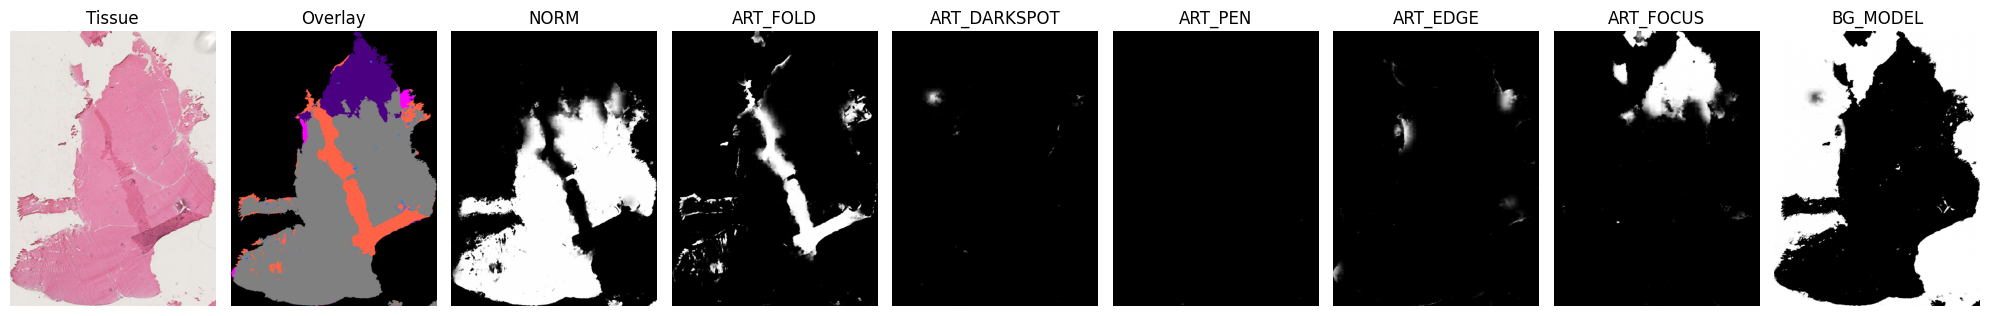

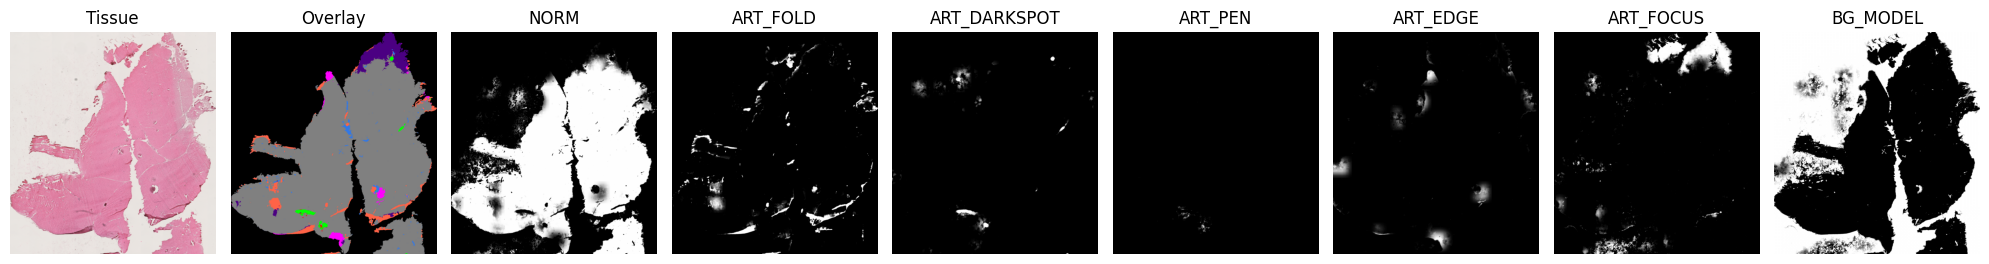

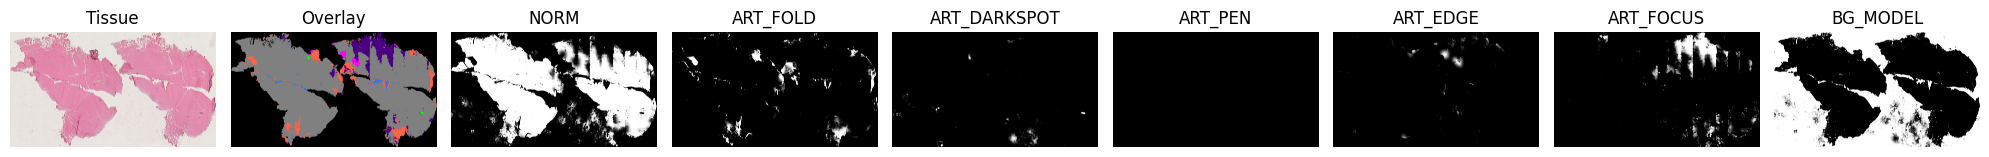

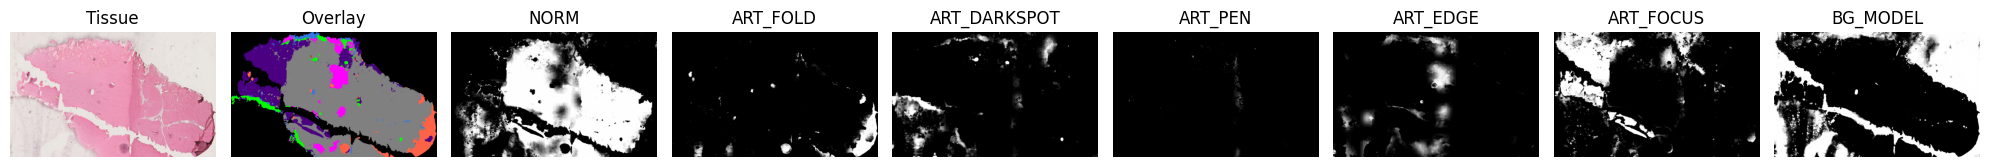

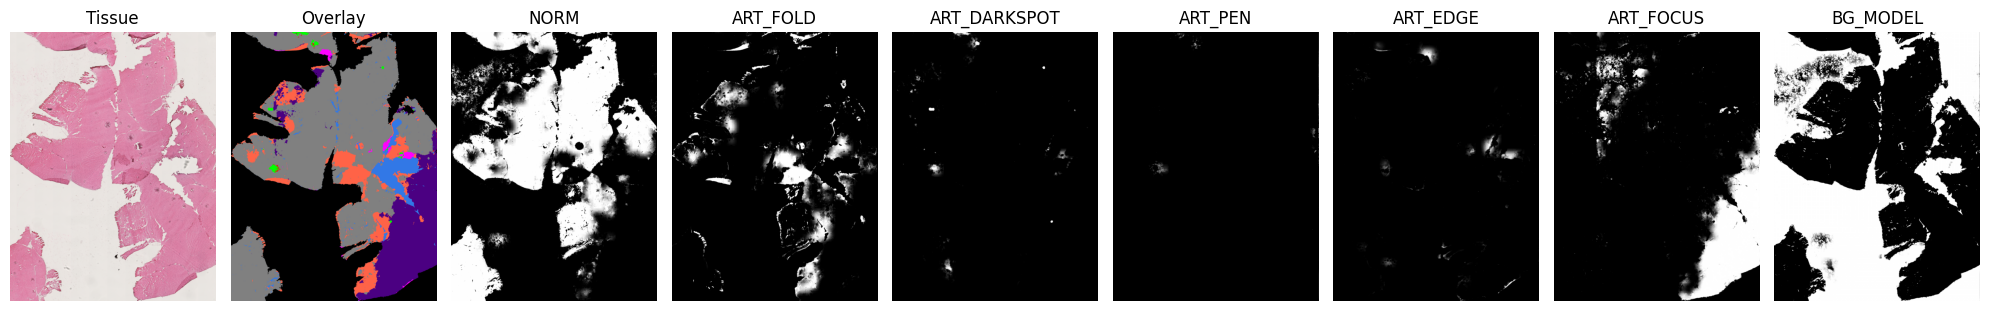

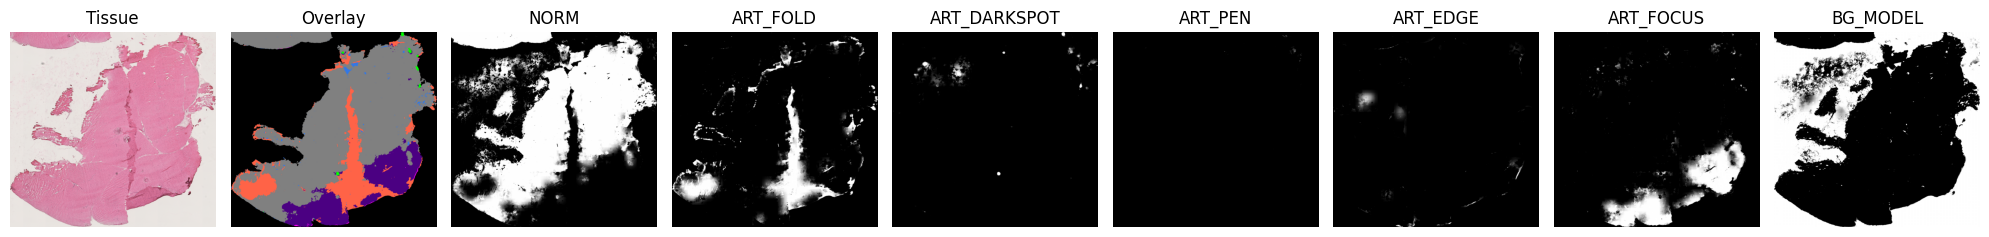

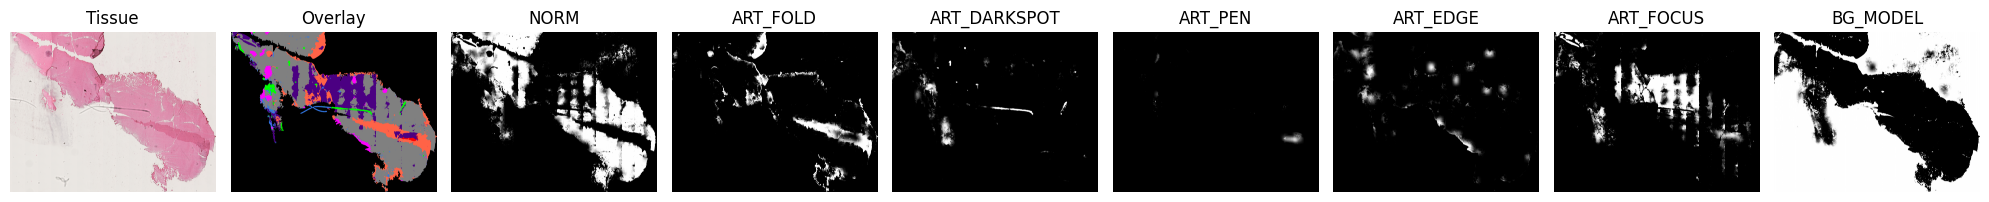

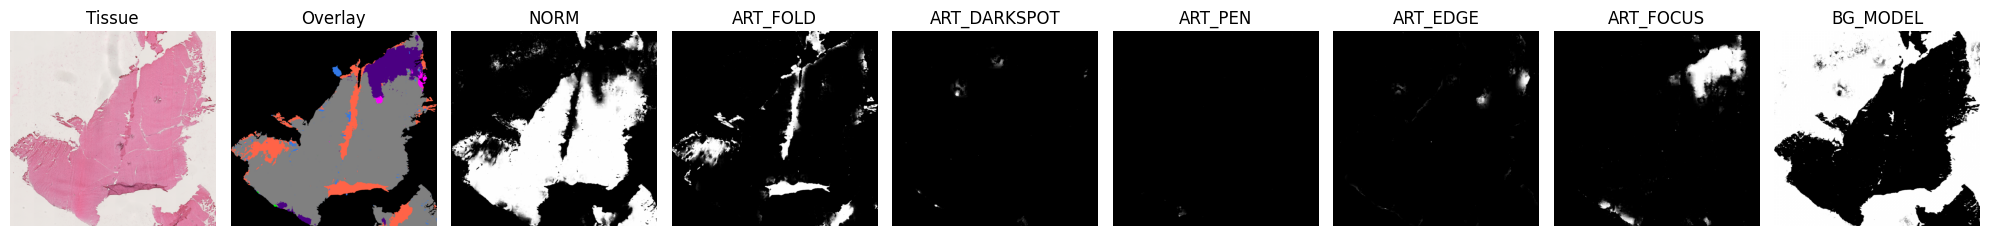

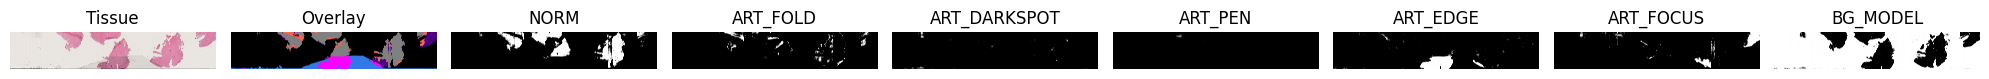

In [6]:
import os
from ipaddress import summarize_address_range

import matplotlib.pyplot as plt
import numpy as np
from src.histo_kit.grand_qc.visualisation import make_artifacts_color_map
from src.histo_kit.utils.wsi import load_wsi_mag
from openslide import OpenSlide
import scipy.io as sio
from src.histo_kit.grand_qc.artifacts import Artifact

wsi_name = "51-21_he"
file = f"/mnt/data/Tmp/jmerta/tmp/maps_51-21_he.mat"
slide = OpenSlide("/mnt/data/Tmp/jmerta/test_data_bbox/51-21_he.svs")
mat = sio.loadmat(f"/mnt/data/Tmp/jmerta/tmp/mask_51-21_he.mat")



data = sio.loadmat(file)
region, scale_val, info, mpp_slide, ratio = load_wsi_mag(slide, 2.5, allow_upscaling=True)

for region_idx in range(mat['bbox'].shape[0]):
    raw_mask_art = data['mask_conf'][0][region_idx]
    bbox=mat['bbox'][region_idx]
    overlay = mat["mask_art"][0][region_idx]
    overlay = make_artifacts_color_map(overlay)
    region_0 = np.array(region)[bbox[0]:bbox[2], bbox[1]:bbox[3], :]



    plt.figure(figsize=(20, 4))

    for ch in range(-1, 8):
        if ch==-1:
            img = region_0
            plt.subplot(1, 9, ch+2)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'Tissue')
        elif ch==0:
            img = overlay
            plt.subplot(1, 9, ch+2)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'Overlay')
        else:
            img = (raw_mask_art[:, :, ch]).astype(np.uint8)
            plt.subplot(1, 9, ch+2)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.title(f'{Artifact(ch).name}')

    plt.tight_layout()
    plt.show()


In [8]:
import glob
import os

masks_processed = glob.glob(os.path.join("/mnt/data/Projects/Compass/Analysis_pipe_v3_10_2025/CompassQC/CompassQC/HE_QC_res/masks/", '*.mat'))
masks_processed.sort(key=os.path.getsize, reverse=True)

masks_grandqc = glob.glob(os.path.join("/mnt/data/Projects/Compass/Analysis_pipe_v3_10_2025/CompassQC/CompassQC/HE_QC_res/masks_grandqc/", '*.mat'))
masks_grandqc_raw = [os.path.basename(p).split(".")[0] for p in masks_grandqc]
with open("files_missing_grandqc.txt", 'w') as f:
    for p in masks_processed:
        base = os.path.basename(p)
        if p not in masks_grandqc_raw:
            svs = os.path.join("/mnt/data/Datasets/Compass/HE/", base.split('.')[0]+'.mat')
            f.write(svs+"\n")

In [13]:
with open("svs_mmserver2.txt", 'r') as f:
    data = f.readlines()


data_all= glob.glob(os.path.join("/mnt/data/Projects/Compass/Analysis_pipe_v3_10_2025/CompassQC/CompassQC/HE_QC_res/masks_grandqc/", '*.mat'))
k=0
all_data_names = [os.path.basename(p).split(".")[0] for p in data_all]
for p in data:
    base_p = os.path.basename(p).split('.')[0]
    if base_p not in all_data_names:
        k=k+1
print(k)

4
